Data setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/SARscope/SARscope"

TRAIN_IMG  = f'{BASE_PATH}/train/'
TRAIN_ANN  = f'{BASE_PATH}/train/_annotations.coco.json'
VALID_IMG  = f'{BASE_PATH}/valid/'
VALID_ANN  = f'{BASE_PATH}/valid/_annotations.coco.json'
TEST_IMG   = f'{BASE_PATH}/test/'
TEST_ANN   = f'{BASE_PATH}/test/_annotations.coco.json'

print("Paths set")

import os
print(f"Checking for file: {TRAIN_ANN}")
if os.path.exists(TRAIN_ANN):
    print("File found!")
else:
    print("File not found. Listing contents of parent directories:")
    print(f"Contents of {BASE_PATH}:")
    print(os.listdir(BASE_PATH))
    print(f"\nContents of {os.path.join(BASE_PATH, 'train')}:")
    print(os.listdir(os.path.join(BASE_PATH, 'train')))

# Now, attempt to initialize COCO again with the corrected path
from pycocotools.coco import COCO
coco_train = COCO(TRAIN_ANN)

print(f"Number of images: {len(coco_train.imgs)}")
print(f"Number of ship annptations {len(coco_train.anns)}")
print(f"Number of categories: {list(c['name'] for c in coco_train.loadCats(coco_train.getCatIds()))}")

In [ ]:
import os

In [ ]:
print(f"Checking for file: {TRAIN_ANN}")
if os.path.exists(TRAIN_ANN):
    print("File found!")
else:
    print("File not found. Listing contents of parent directories:")
    print(f"Contents of {BASE_PATH}:")
    print(os.listdir(BASE_PATH))
    print(f"\nContents of {os.path.join(BASE_PATH, 'train')}:")
    print(os.listdir(os.path.join(BASE_PATH, 'train')))

Checking for file: /content/drive/MyDrive/SARscope/SARscope/train/_annotations.coco.json
File found!


Libraries setup

In [ ]:
!pip install folium --quiet

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input, Concatenate, SimpleRNN, LSTM, Flatten, BatchNormalization, Conv2D, Dropout
from pycocotools.coco import COCO

In [ ]:
tf.__version__

'2.20.0'

Visualiztion

In [ ]:
coco_train = COCO(TRAIN_ANN)

print(f"Number of images: {len(coco_train.imgs)}")
print(f"Number of ship annptations {len(coco_train.anns)}")
print(f"Number of categories: {list(c['name'] for c in coco_train.loadCats(coco_train.getCatIds()))}")

img_ids_with_ships = list(set([ann['image_id'] for ann in coco_train.anns.values()]))
img_ids_all        = list(coco_train.imgs.keys())
img_ids_no_ships   = [i for i in img_ids_all if i not in img_ids_with_ships]

print(f"\nImages WITH ships:        {len(img_ids_with_ships)}")
print(f"Images WITHOUT ships:     {len(img_ids_no_ships)}")

loading annotations into memory...
Done (t=0.40s)
creating index...
index created!
Number of images: 4717
Number of ship annptations 13640
Number of categories: ['ship']

Images WITH ships:        4716
Images WITHOUT ships:     1


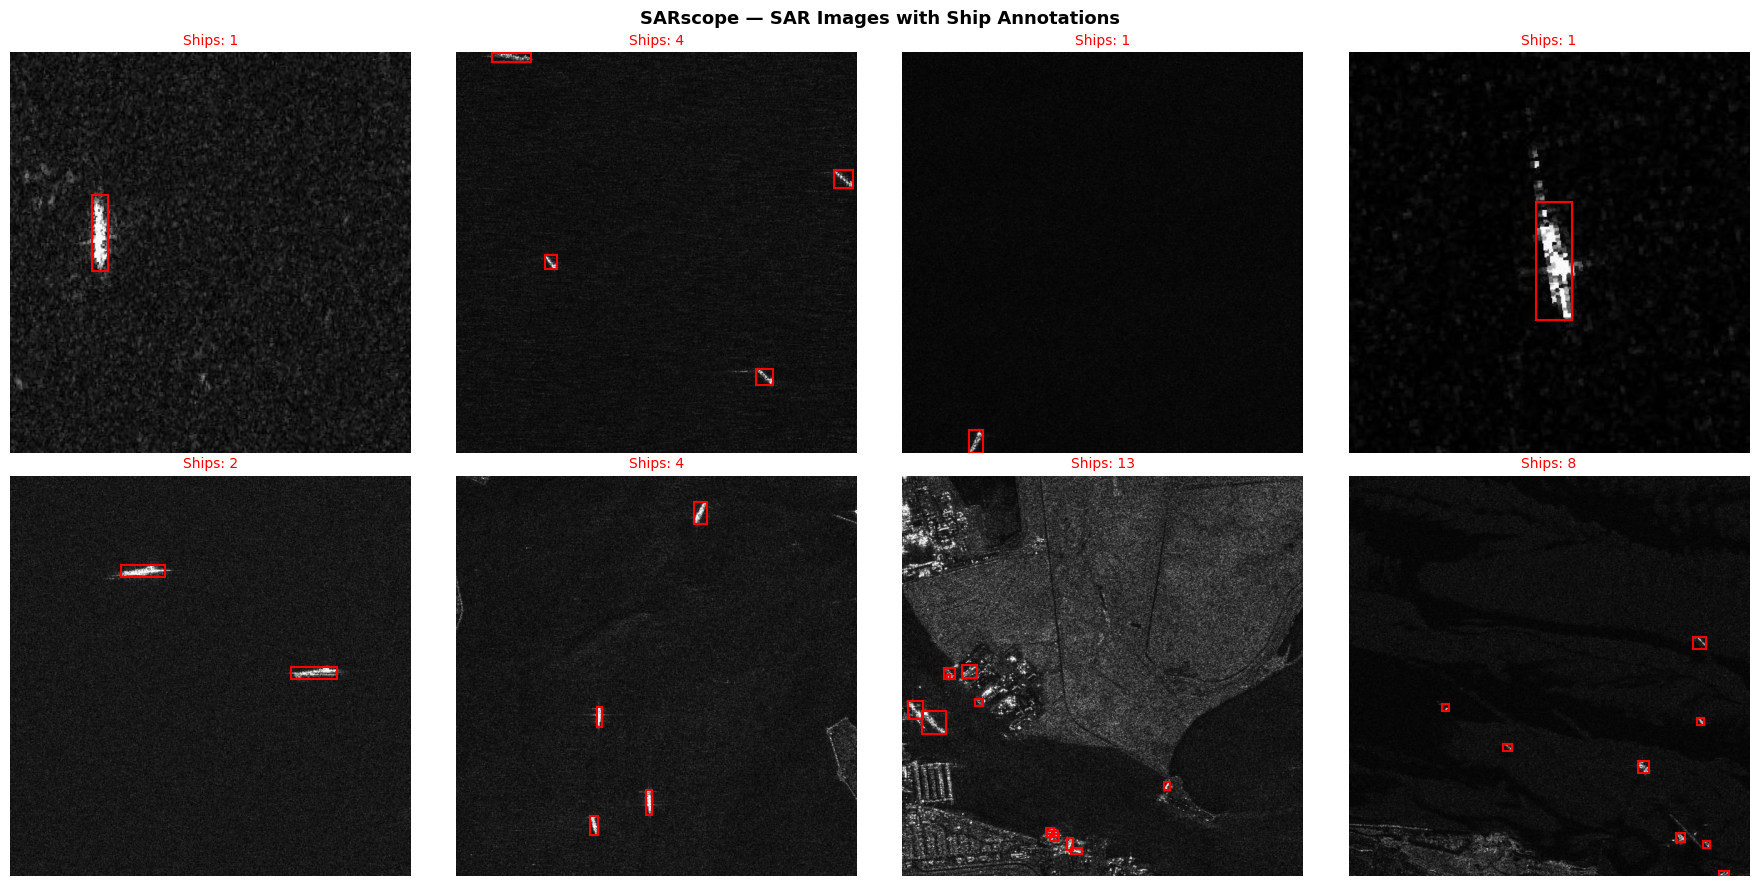

Done


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random
import os

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

# Just pick 8 random images from the dataset
sample_ids = random.sample(list(coco_train.imgs.keys()), 8)

for idx, img_id in enumerate(sample_ids):
    img_info = coco_train.loadImgs(img_id)[0]
    img_path = os.path.join(TRAIN_IMG, img_info['file_name'])

    try:
        img = Image.open(img_path).convert('RGB')
        axes[idx].imshow(img)

        # Draw bounding boxes
        ann_ids = coco_train.getAnnIds(imgIds=img_id)
        anns    = coco_train.loadAnns(ann_ids)

        for ann in anns:
            x, y, w, h = ann['bbox']
            rect = patches.Rectangle(
                (x, y), w, h,
                linewidth=1.5,
                edgecolor='red',
                facecolor='none'
            )
            axes[idx].add_patch(rect)

        axes[idx].set_title(f"Ships: {len(anns)}", fontsize=10, color='red')

    except Exception as e:
        axes[idx].set_title(f"Error: {e}", fontsize=8)

    axes[idx].axis('off')

plt.suptitle('SARscope — SAR Images with Ship Annotations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sar_visualization.png', dpi=150)
plt.show()
print("Done")

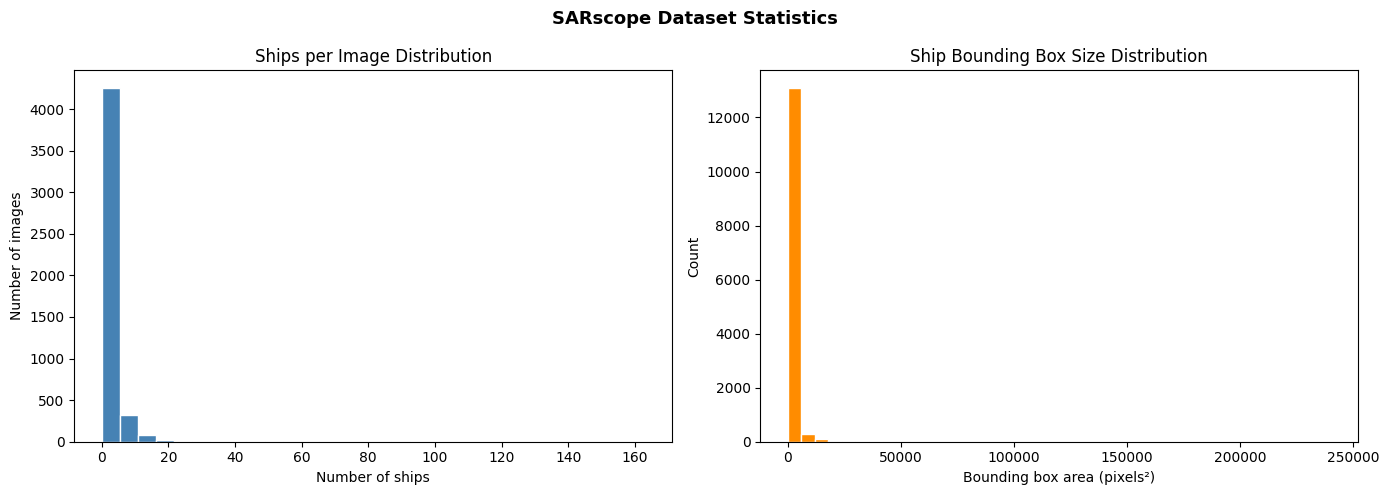

Average ships per image: 2.89
Max ships in one image:  163
Images with 0 ships:     1


In [ ]:
import matplotlib.pyplot as plt

# Count ships per image
ships_per_image = []
for img_id in list(coco_train.imgs.keys()):
    ann_ids = coco_train.getAnnIds(imgIds=img_id)
    ships_per_image.append(len(ann_ids))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — distribution
axes[0].hist(ships_per_image, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Ships per Image Distribution')
axes[0].set_xlabel('Number of ships')
axes[0].set_ylabel('Number of images')

# Plot 2 — bounding box sizes
bbox_areas = []
for ann in coco_train.anns.values():
    w, h = ann['bbox'][2], ann['bbox'][3]
    bbox_areas.append(w * h)

axes[1].hist(bbox_areas, bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Ship Bounding Box Size Distribution')
axes[1].set_xlabel('Bounding box area (pixels²)')
axes[1].set_ylabel('Count')

plt.suptitle('SARscope Dataset Statistics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dataset_stats.png', dpi=150)
plt.show()

print(f"Average ships per image: {sum(ships_per_image)/len(ships_per_image):.2f}")
print(f"Max ships in one image:  {max(ships_per_image)}")
print(f"Images with 0 ships:     {ships_per_image.count(0)}")

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, Dropout,
    BatchNormalization, Input
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import numpy as np


print("building dataset at 96x96...")

def build_dataset(img_dir, ann_path, img_size=96, max_samples=2000, threshold=2):
    from pycocotools.coco import COCO
    from PIL import Image
    import random, os

    coco = COCO(ann_path)
    images, labels = [], []

    img_ids_all = list(coco.imgs.keys())
    random.seed(42)
    random.shuffle(img_ids_all)
    img_ids_all = img_ids_all[:max_samples]

    print(f"Loading {len(img_ids_all)} images at {img_size}x{img_size}...")
    for i, img_id in enumerate(img_ids_all):
        if i % 200 == 0:
            print(f"  {i}/{len(img_ids_all)}...")
        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(img_dir, img_info['file_name'])
        try:
            img = Image.open(img_path).convert('RGB')
            img = img.resize((img_size, img_size))
            ann_count = len(coco.getAnnIds(imgIds=img_id))
            images.append(np.array(img) / 255.0)
            labels.append(1 if ann_count >= threshold else 0)
        except:
            continue

    X = np.array(images, dtype=np.float32)
    y = np.array(labels)
    print(f"High density: {y.sum()} ({y.mean()*100:.1f}%) | Low density: {(y==0).sum()}")
    return X, y

X_train, y_train = build_dataset(TRAIN_IMG, TRAIN_ANN, img_size=96, max_samples=2000, threshold=2)
X_valid, y_valid = build_dataset(VALID_IMG, VALID_ANN, img_size=96, max_samples=500,  threshold=2)
X_test,  y_test  = build_dataset(TEST_IMG,  TEST_ANN,  img_size=96, max_samples=500,  threshold=2)

# Save
SAVE_PATH = '/content/drive/MyDrive/dark_fleet_project/processed_data'
np.save(f"{SAVE_PATH}/train_X_v4.npy", X_train)
np.save(f"{SAVE_PATH}/train_y_v4.npy", y_train)
np.save(f"{SAVE_PATH}/valid_X_v4.npy", X_valid)
np.save(f"{SAVE_PATH}/valid_y_v4.npy", y_valid)
np.save(f"{SAVE_PATH}/test_X_v4.npy",  X_test)
np.save(f"{SAVE_PATH}/test_y_v4.npy",  y_test)
print("Saved ")

building dataset at 96x96...
loading annotations into memory...
Done (t=0.40s)
creating index...
index created!
Loading 2000 images at 96x96...
  0/2000...
  200/2000...
  400/2000...
  600/2000...
  800/2000...
  1000/2000...
  1200/2000...
  1400/2000...
  1600/2000...
  1800/2000...
High density: 1002 (50.1%) | Low density: 998
loading annotations into memory...
Done (t=5.56s)
creating index...
index created!
Loading 500 images at 96x96...
  0/500...
  200/500...
  400/500...
High density: 237 (47.4%) | Low density: 263
loading annotations into memory...
Done (t=3.33s)
creating index...
index created!
Loading 500 images at 96x96...
  0/500...
  200/500...
  400/500...
High density: 252 (50.4%) | Low density: 248
Saved 


CNN model

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, Flatten, BatchNormalization, Input
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2

def build_cnn_transfer(input_shape=(96, 96, 3)):
    base = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    # Freeze base first
    base.trainable = False

    inputs = Input(shape=input_shape)
    x = base(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(128, activation='relu', kernel_regularizer= tf.keras.regularizers.l2(0.05))(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='relu', kernel_regularizer= tf.keras.regularizers.l2(0.05))(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model

cnn_model = build_cnn_transfer()
cnn_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,435,393 (9.29 MB)

 Trainable params: 174,849 (683.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
# Class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class weights: {class_weight_dict}")

Class weights: {0: np.float64(1.002004008016032), 1: np.float64(0.998003992015968)}


In [ ]:
# Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(X_train)

In [ ]:
# Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
callbacks = [
    EarlyStopping(
        monitor='val_auc',
        patience=6,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        mode='max',
        verbose=1
    )
]

In [ ]:
print("\nPhase 1 — Training classifier head...")
history1 = cnn_model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=15,
    validation_data=(X_valid, y_valid),
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)


Phase 1 — Training classifier head...
Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 56s 580ms/step - accuracy: 0.7920 - auc: 0.8464 - loss: 9.1557 - precision: 0.8199 - recall: 0.7495 - val_accuracy: 0.8680 - val_auc: 0.9157 - val_loss: 4.1870 - val_precision: 0.8800 - val_recall: 0.8354 - learning_rate: 0.0010
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.8400 - auc: 0.8952 - loss: 2.5152 - precision: 0.8698 - recall: 0.8004 - val_accuracy: 0.8440 - val_auc: 0.9148 - val_loss: 1.4262 - val_precision: 0.8664 - val_recall: 0.7932 - learning_rate: 0.0010
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.8240 - auc: 0.8865 - loss: 1.0795 - precision: 0.8571 - recall: 0.7784 - val_accuracy: 0.8680 - val_auc: 0.9207 - val_loss: 0.7773 - val_precision: 0.8767 - val_recall: 0.8397 - learning_rate: 0.0010
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.8450 - auc: 0.9019 - loss: 0.6829 - precision: 0.8704 - recall: 0.8114 - val_accuracy: 0.8600 - val

In [ ]:
# Phase 2 — unfreeze top layers of MobileNetV2 and fine tune
base_model = cnn_model.layers[1]
base_model.trainable = True

# unfreeze last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False


In [ ]:
# Recompile with lower learning rate
cnn_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [ ]:
# Reset callbacks
callbacks2 = [
    EarlyStopping(
        monitor='val_auc',
        patience=6,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.5,
        patience=3,
        min_lr=1e-8,
        mode='max',
        verbose=1
    )
]

In [ ]:
# Training
print("Phase 2 — Fine tuning...")
history2 = cnn_model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=15,
    validation_data=(X_valid, y_valid),
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

Phase 2 — Fine tuning...
Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 43s 384ms/step - accuracy: 0.7900 - auc: 0.8481 - loss: 0.6552 - precision: 0.7836 - recall: 0.8024 - val_accuracy: 0.8600 - val_auc: 0.9292 - val_loss: 0.4778 - val_precision: 0.8744 - val_recall: 0.8228 - learning_rate: 1.0000e-05
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - accuracy: 0.8325 - auc: 0.8911 - loss: 0.5851 - precision: 0.8514 - recall: 0.8064 - val_accuracy: 0.8500 - val_auc: 0.9253 - val_loss: 0.4830 - val_precision: 0.8785 - val_recall: 0.7932 - learning_rate: 1.0000e-05
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8428 - auc: 0.8986 - loss: 0.5600 - precision: 0.8566 - recall: 0.8193
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.8405 - auc: 0.8983 - loss: 0.5566 - precision: 0.8606 - recall: 0.8134 - val_accuracy: 0.8480 - val_auc: 0.9261 - val_loss: 0.4971 - val_precision: 0.8889 - val_recall:

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Final evaluation
results = cnn_model.evaluate(X_test, y_test, verbose=0)
print(f"CNN Branch — Final Test Results")
print(f"Accuracy:  {results[1]*100:.2f}%")
print(f"AUC:       {results[2]:.4f}")
print(f"Precision: {results[3]:.4f}")
print(f"Recall:    {results[4]:.4f}")

y_pred = (cnn_model.predict(X_test) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=['Low density', 'High density']
))


CNN Branch — Final Test Results
Accuracy:  89.60%
AUC:       0.9645
Precision: 0.9167
Recall:    0.8730
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 280ms/step

Classification Report:
              precision    recall  f1-score   support

 Low density       0.88      0.92      0.90       248
High density       0.92      0.87      0.89       252

    accuracy                           0.90       500
   macro avg       0.90      0.90      0.90       500
weighted avg       0.90      0.90      0.90       500



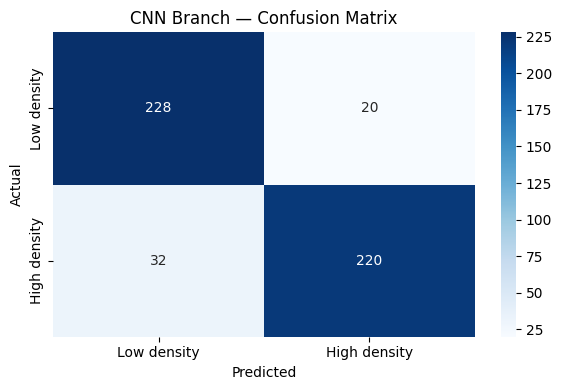

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low density', 'High density'],
            yticklabels=['Low density', 'High density'])
plt.title('CNN Branch — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150)
plt.show()

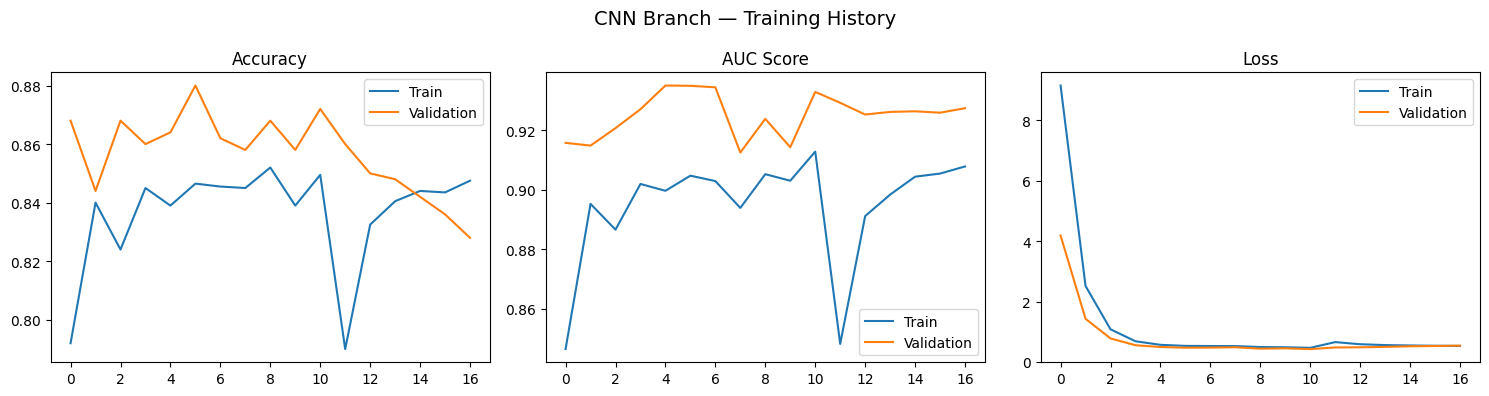

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Combine histories for plotting
combined_history = {}
for key in history1.history.keys():
    combined_history[key] = history1.history[key] + history2.history[key]

# Accuracy
axes[0].plot(combined_history['accuracy'],     label='Train')
axes[0].plot(combined_history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].legend()

# AUC
axes[1].plot(combined_history['auc'],     label='Train')
axes[1].plot(combined_history['val_auc'], label='Validation')
axes[1].set_title('AUC Score')
axes[1].legend()

# Loss
axes[2].plot(combined_history['loss'],     label='Train')
axes[2].plot(combined_history['val_loss'], label='Validation')
axes[2].set_title('Loss')
axes[2].legend()

plt.suptitle('CNN Branch — Training History', fontsize=14)
plt.tight_layout()
plt.savefig('cnn_training_history.png', dpi=150)
plt.show()

In [ ]:
import os
os.makedirs('/content/drive/MyDrive/dark_fleet_project/models', exist_ok=True)

cnn_model.save('/content/drive/MyDrive/dark_fleet_project/models/cnn_branch.keras')

cnn_scores_train = cnn_model.predict(X_train).flatten()
cnn_scores_test  = cnn_model.predict(X_test).flatten()

np.save('/content/drive/MyDrive/dark_fleet_project/models/cnn_scores_train.npy', cnn_scores_train)
np.save('/content/drive/MyDrive/dark_fleet_project/models/cnn_scores_test.npy',  cnn_scores_test)
print("CNN branch saved")

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
CNN branch saved


Data setup for LSTM

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import os

GFW = '/content/drive/MyDrive/SAR dataset'

df_march = pd.read_csv(f'{GFW}/sar_vessel_detections_pipev4_202603.csv')
print(f"\nTotal rows: {len(df_march)}")
print(f"Total columns: {list(df_march.columns)}")
print(f"\n matched_category breakdown:")
print(df_march["matched_category"].value_counts())
print(f"\n sample:")
df_march.head()


Total rows: 107257
Total columns: ['scene_id', 'timestamp', 'lat', 'lon', 'presence_score', 'length_m', 'mmsi', 'matching_score', 'fishing_score', 'matched_category']

 matched_category breakdown:
matched_category
unmatched         42455
other             25799
cargo             23473
fishing            9309
noisy_vessel       2198
passenger          2125
seismic_vessel      831
gear                589
carrier             329
bunker              149
Name: count, dtype: int64

 sample:


,scene_id,timestamp,lat,lon,presence_score,length_m,mmsi,matching_score,fishing_score,matched_category
0,S1A_IW_GRDH_1SDV_20260301T025938_20260301T0300...,2026-03-01 02:59:51 UTC,15.073154,42.589362,0.996075,298.876434,636018944.0,3.364264,0.031119,bunker
1,S1A_IW_GRDH_1SDV_20260301T030028_20260301T0300...,2026-03-01 03:00:41 UTC,11.800995,43.199889,0.997674,222.860611,215282000.0,73.570273,0.012883,bunker
2,S1A_IW_GRDH_1SDV_20260301T030028_20260301T0300...,2026-03-01 03:00:41 UTC,11.678201,43.116715,0.996415,109.834343,357132000.0,95.948676,0.012883,bunker
3,S1A_IW_GRDH_1SDV_20260301T030028_20260301T0300...,2026-03-01 03:00:41 UTC,11.671123,43.112474,0.996966,40.395306,620094000.0,463.678624,0.194723,bunker
4,S1A_IW_GRDH_1SDV_20260301T043201_20260301T0432...,2026-03-01 04:32:14 UTC,38.025432,23.521872,0.993507,127.310089,215013000.0,557.370397,0.012883,bunker


FIlter to indian ocean

In [ ]:
# Indian Ocean bounding box
df_indian = df_march[
    (df_march['lat'] >= -30) & (df_march['lat'] <= 30) &
    (df_march['lon'] >= 40)  & (df_march['lon'] <= 100)
].copy()

# Create dark vessel label
df_indian['dark_vessel'] = (
    df_indian['matched_category'] == 'unmatched'
).astype(int)

# Parse timestamp
df_indian['timestamp'] = pd.to_datetime(
    df_indian['timestamp'], utc=True
)

print(f"Indian Ocean records: {len(df_indian):,}")
print(f"Dark vessels: {df_indian['dark_vessel'].sum():,}")
print(f"Normal vessels: {(df_indian['dark_vessel']==0).sum():,}")
print(f"\nUnique MMSI (identified vessels): {df_indian['mmsi'].nunique():,}")
print(f"Unmatched (no MMSI): {df_indian['mmsi'].isna().sum():,}")

Indian Ocean records: 16,795
Dark vessels: 11,136
Normal vessels: 5,659

Unique MMSI (identified vessels): 6,072
Unmatched (no MMSI): 8,798


In [ ]:
# Feature engineering

# Feature engineering per detection
df_indian['hour']      = df_indian['timestamp'].dt.hour
df_indian['day']       = df_indian['timestamp'].dt.day
df_indian['dayofweek'] = df_indian['timestamp'].dt.dayofweek

# For vessels with multiple detections — calculate movement features
df_indian['lat_diff'] = df_indian.groupby('mmsi')['lat'].diff().fillna(0)
df_indian['lon_diff'] = df_indian.groupby('mmsi')['lon'].diff().fillna(0)
df_indian['time_diff'] = df_indian.groupby('mmsi')['timestamp'].diff().dt.total_seconds().fillna(0)

# Speed proxy — distance moved per second
df_indian['speed_proxy'] = np.sqrt(
    df_indian['lat_diff']**2 + df_indian['lon_diff']**2
) / (df_indian['time_diff'] + 1e-6)

# Flag impossible speeds (spoofing indicator)
df_indian['impossible_speed'] = (df_indian['speed_proxy'] > 0.001).astype(int)

print("Features engineered ")
print(df_indian[['lat', 'lon', 'speed_proxy', 'impossible_speed', 'dark_vessel']].describe())


Features engineered 
                lat           lon   speed_proxy  impossible_speed  \
count  16795.000000  16795.000000  16795.000000      16795.000000   
mean      18.825062     71.978742      0.000156          0.008276   
std        8.377784     18.964752      0.002156          0.090599   
min      -25.788934     40.003731     -0.021256          0.000000   
25%       14.072938     54.266199      0.000000          0.000000   
50%       21.159109     70.210570      0.000000          0.000000   
75%       25.360198     91.774033      0.000000          0.000000   
max       29.965636     99.999117      0.079328          1.000000   

        dark_vessel  
count  16795.000000  
mean       0.663054  
std        0.472680  
min        0.000000  
25%        0.000000  
50%        1.000000  
75%        1.000000  
max        1.000000  


In [ ]:
SEQUENCE_LENGTH = 2
FEATURES = [
    'lat', 'lon',
    'presence_score', 'length_m',
    'fishing_score', 'matching_score',
    'hour', 'dayofweek',
    'lat_diff', 'lon_diff',
    'speed_proxy', 'impossible_speed'
]

def build_sequences(df, seq_len=2, min_detections=2):
    sequences = []
    labels    = []

    df_mmsi = df[df['mmsi'].notna()].copy()
    df_mmsi[FEATURES] = df_mmsi[FEATURES].fillna(0)

    grouped = df_mmsi.groupby('mmsi')

    for mmsi, group in grouped:
        group = group.sort_values('timestamp')

        if len(group) < min_detections:
            continue

        feat_matrix = group[FEATURES].values
        dark_ratio = group['dark_vessel'].mean()
        label = 1 if dark_ratio >= 0.5 else 0

        for i in range(len(feat_matrix) - seq_len + 1):
            seq = feat_matrix[i:i + seq_len]
            sequences.append(seq)
            labels.append(label)

    return np.array(sequences, dtype=np.float32), np.array(labels)


print("Building sequences with seq_len=2...")
X_seq, y_seq = build_sequences(df_indian, seq_len=SEQUENCE_LENGTH, min_detections=2)

print(f"\nSequences shape: {X_seq.shape}")
print(f"Dark sequences:   {y_seq.sum():,} ({y_seq.mean()*100:.1f}%)")
print(f"Normal sequences: {(y_seq==0).sum():,} ({(1-y_seq.mean())*100:.1f}%)")

Building sequences with seq_len=2...

Sequences shape: (1925, 2, 12)
Dark sequences:   503 (26.1%)
Normal sequences: 1,422 (73.9%)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import os
import numpy as np # Ensure numpy is imported for np.unique

# Check if there are enough samples and classes for train_test_split with stratification
if X_seq.shape[0] < 2 or np.unique(y_seq).shape[0] < 2:
    print("Warning: Not enough samples or classes to perform a proper stratified train_test_split.")
    print("Root cause: The 'build_sequences' function in the previous cell generated too few sequences.")
    print("Assigning all available data to train, validation, and test sets. Please consider adjusting 'SEQUENCE_LENGTH' or 'min_detections' in 'build_sequences' to generate more data.")
    X_tr = X_seq
    X_val = X_seq # Using X_seq for validation as well
    X_te = X_seq
    y_tr = y_seq
    y_val = y_seq # Using y_seq for validation as well
    y_te = y_seq
else:
    # Original Split
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_seq, y_seq,
        test_size=0.2,
        random_state=42,
        stratify=y_seq
    )
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_tr, y_tr,
        test_size=0.2,
        random_state=42,
        stratify=y_tr
    )

# Scale features (only if data exists)
if X_tr.shape[0] > 0:
    n_samples, n_steps, n_features = X_tr.shape
    scaler = StandardScaler()

    X_tr_scaled  = scaler.fit_transform(X_tr.reshape(-1, n_features)).reshape(X_tr.shape)
    X_val_scaled = scaler.transform(X_val.reshape(-1, n_features)).reshape(X_val.shape)
    X_te_scaled  = scaler.transform(X_te.reshape(-1, n_features)).reshape(X_te.shape)

    print(f"Train:      {X_tr_scaled.shape} | Dark: {y_tr.mean()*100:.1f}%")
    print(f"Validation: {X_val_scaled.shape} | Dark: {y_val.mean()*100:.1f}%")
    print(f"Test:       {X_te_scaled.shape} | Dark: {y_te.mean()*100:.1f}%")

    # Save scaler
    os.makedirs('/content/drive/MyDrive/dark_fleet_project/models', exist_ok=True)
    joblib.dump(scaler, '/content/drive/MyDrive/dark_fleet_project/models/lstm_scaler.pkl')
    print("Scaler saved")
else:
    print("No data available for scaling or saving scaler after handling splits.")

Train:      (1232, 2, 12) | Dark: 26.1%
Validation: (308, 2, 12) | Dark: 26.0%
Test:       (385, 2, 12) | Dark: 26.2%
Scaler saved


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout,
    BatchNormalization, Bidirectional
)
from tensorflow.keras.optimizers import Adam

def build_lstm_model(seq_len, n_features):
    inputs = Input(shape=(seq_len, n_features))


    x = Bidirectional(LSTM(64, return_sequences=True))(inputs)
    x = Dropout(0.3)(x)
    x = Bidirectional(LSTM(32))(x)
    x = Dropout(0.3)(x)
    x = BatchNormalization()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model

lstm_model = build_lstm_model(SEQUENCE_LENGTH, len(FEATURES))
lstm_model.summary()



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 2, 12)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 2, 128)         │        39,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,121 (332.50 KB)

 Trainable params: 84,993 (332.00 KB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
# Class weights
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
cw_dict = {0: cw[0], 1: cw[1]}
print(f"\nClass weights: {cw_dict}")



Class weights: {0: np.float64(0.676923076923077), 1: np.float64(1.9130434782608696)}


In [ ]:
# Callbacks
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
lstm_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=7,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/dark_fleet_project/models/lstm_best.keras',
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

In [ ]:
# Train
history_lstm = lstm_model.fit(
    X_tr_scaled, y_tr,
    epochs=40,
    batch_size=64,
    validation_data=(X_val_scaled, y_val),
    callbacks=lstm_callbacks,
    class_weight=cw_dict,
    verbose=1
)

Epoch 1/40
16/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5646 - auc: 0.6190 - loss: 0.6943 - precision: 0.3470 - recall: 0.6256
Epoch 1: val_auc improved from None to 0.85044, saving model to /content/drive/MyDrive/dark_fleet_project/models/lstm_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/dark_fleet_project/models/lstm_best.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - accuracy: 0.6672 - auc: 0.7479 - loss: 0.5866 - precision: 0.4170 - recall: 0.6863 - val_accuracy: 0.8409 - val_auc: 0.8504 - val_loss: 0.6541 - val_precision: 0.7123 - val_recall: 0.6500 - learning_rate: 0.0010
Epoch 2/40
16/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7780 - auc: 0.8330 - loss: 0.4946 - precision: 0.5558 - recall: 0.6995
Epoch 2: val_auc improved from 0.85044 to 0.86538, saving model to /content/drive/MyDrive/dark_fleet_project/models/lstm_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/dark_fleet_project/models/lstm_best.keras
20/20 ━━━━━━

Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
results = lstm_model.evaluate(X_te_scaled, y_te, verbose=0)
print(f"\n{'='*45}")
print(f"LSTM Branch — Final Test Results")
print(f"{'='*45}")
print(f"Accuracy:  {results[1]*100:.2f}%")
print(f"AUC:       {results[2]:.4f}")
print(f"Precision: {results[3]:.4f}")
print(f"Recall:    {results[4]:.4f}")

y_pred = (lstm_model.predict(X_te_scaled) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(
    y_te, y_pred,
    target_names=['Normal vessel', 'Dark vessel']
))


LSTM Branch — Final Test Results
Accuracy:  86.23%
AUC:       0.9291
Precision: 0.7000
Recall:    0.8317
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step

Classification Report:
               precision    recall  f1-score   support

Normal vessel       0.94      0.87      0.90       284
  Dark vessel       0.70      0.83      0.76       101

     accuracy                           0.86       385
    macro avg       0.82      0.85      0.83       385
 weighted avg       0.87      0.86      0.87       385



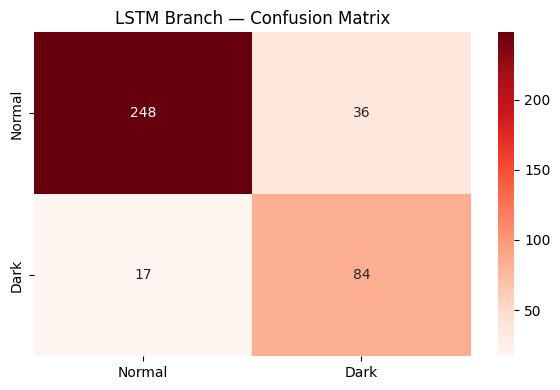

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Normal','Dark'],
            yticklabels=['Normal','Dark'])
plt.title('LSTM Branch — Confusion Matrix')
plt.tight_layout()
plt.savefig('lstm_confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
# Save scores for fusion
lstm_scores_train = lstm_model.predict(X_tr_scaled).flatten()
lstm_scores_test  = lstm_model.predict(X_te_scaled).flatten()

np.save('/content/drive/MyDrive/dark_fleet_project/models/lstm_scores_train.npy', lstm_scores_train)
np.save('/content/drive/MyDrive/dark_fleet_project/models/lstm_scores_test.npy',  lstm_scores_test)
np.save('/content/drive/MyDrive/dark_fleet_project/models/lstm_y_train.npy', y_tr)
np.save('/content/drive/MyDrive/dark_fleet_project/models/lstm_y_test.npy',  y_te)

print("LSTM branch complete and saved")

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
LSTM branch complete and saved


RNN model

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, BatchNormalization, SimpleRNN, Input, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

def build_rnn_model(seq_len, n_features):
  inputs = Input(shape=(seq_len, n_features))

  x = SimpleRNN(64, return_sequences=True, activation='tanh')(inputs)
  x = Dropout(0.3)(x)
  x = SimpleRNN(32, activation = 'tanh')(x)
  x = Dropout(0.3)(x)
  x = BatchNormalization()(x)
  x = Dense(32, activation = 'relu')(x)
  x = Dropout(0.2)(x)
  output = Dense(1, activation='sigmoid')(x)

  model = Model(inputs=inputs, outputs=output)
  model.compile(
      optimizer=Adam(learning_rate=0.001),
      loss='binary_crossentropy',
      metrics=[
          'accuracy',
          tf.keras.metrics.AUC(name='auc'),
          tf.keras.metrics.Precision(name='precision'),
          tf.keras.metrics.Recall(name='recall')
      ]
  )
  return model

rnn_model = build_rnn_model(SEQUENCE_LENGTH, len(FEATURES))
rnn_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 2, 12)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 2, 64)          │         4,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,249 (36.13 KB)

 Trainable params: 9,185 (35.88 KB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
# callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
early_stopping = EarlyStopping(
    monitor='val_auc',
    patience=7,
    restore_best_weights=True,
    mode='max',
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    mode='max',
    verbose=1
)
model_checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/dark_fleet_project/models/rnn_best.keras',
    monitor='val_auc',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [ ]:
history = rnn_model.fit(
    X_tr_scaled, y_tr,
    epochs=40,
    batch_size=64,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stopping, reduce_lr, model_checkpoint],
    class_weight=cw_dict,
    verbose = 1
)

Epoch 1/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.4728 - auc: 0.5334 - loss: 0.7748 - precision: 0.2874 - recall: 0.6637
Epoch 1: val_auc improved from None to 0.76165, saving model to /content/drive/MyDrive/dark_fleet_project/models/rnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/dark_fleet_project/models/rnn_best.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 381ms/step - accuracy: 0.5179 - auc: 0.5998 - loss: 0.7177 - precision: 0.3116 - recall: 0.6988 - val_accuracy: 0.7403 - val_auc: 0.7617 - val_loss: 0.5772 - val_precision: 0.5000 - val_recall: 0.7000 - learning_rate: 0.0010
Epoch 2/40
16/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6722 - auc: 0.7464 - loss: 0.6255 - precision: 0.4735 - recall: 0.7275 
Epoch 2: val_auc improved from 0.76165 to 0.81302, saving model to /content/drive/MyDrive/dark_fleet_project/models/rnn_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/dark_fleet_project/models/rnn_best.keras
20/20 ━━━━━━━━

Evaluation of RNN model


RNN Branch — Final Test Results
Accuracy:  83.38%
AUC:       0.9276
Precision: 0.6434
Recall:    0.8218
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step

Classification Report:
               precision    recall  f1-score   support

Normal vessel       0.93      0.84      0.88       284
  Dark vessel       0.64      0.82      0.72       101

     accuracy                           0.83       385
    macro avg       0.79      0.83      0.80       385
 weighted avg       0.85      0.83      0.84       385



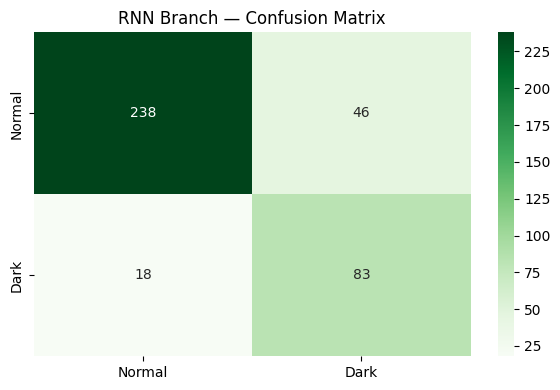

In [ ]:
import matplotlib.pyplot as plt

results = rnn_model.evaluate(X_te_scaled, y_te, verbose=0)
print(f"\n{'='*45}")
print(f"RNN Branch — Final Test Results")
print(f"{'='*45}")
print(f"Accuracy:  {results[1]*100:.2f}%")
print(f"AUC:       {results[2]:.4f}")
print(f"Precision: {results[3]:.4f}")
print(f"Recall:    {results[4]:.4f}")

y_pred = (rnn_model.predict(X_te_scaled) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(
    y_te, y_pred,
    target_names=['Normal vessel', 'Dark vessel']
))

cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal','Dark'],
            yticklabels=['Normal','Dark'])
plt.title('RNN Branch — Confusion Matrix')
plt.tight_layout()
plt.savefig('rnn_confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
# Save scores for fusion
rnn_scores_train = rnn_model.predict(X_tr_scaled).flatten()
rnn_scores_test  = rnn_model.predict(X_te_scaled).flatten()

np.save('/content/drive/MyDrive/dark_fleet_project/models/rnn_scores_train.npy', rnn_scores_train)
np.save('/content/drive/MyDrive/dark_fleet_project/models/rnn_scores_test.npy',  rnn_scores_test)

print("RNN branch complete")

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
RNN branch complete


In [ ]:
print(df_indian['matching_score'].describe())
print(f"\nBy category:")
print(df_indian.groupby('matched_category')['matching_score'].mean())

count    16795.000000
mean        28.023131
std        124.545200
min          0.000000
25%          0.000000
50%          0.000000
75%          0.653095
max       1427.243941
Name: matching_score, dtype: float64

By category:
matched_category
bunker             70.149443
cargo              43.134441
carrier             9.033328
fishing            64.558793
gear               21.274732
noisy_vessel       56.259830
other             108.669883
passenger          67.142478
seismic_vessel    209.503787
unmatched           0.000309
Name: matching_score, dtype: float64


Fusion layers

In [ ]:
import numpy as np

MODELS_PATH = '/content/drive/MyDrive/dark_fleet_project/models'

# Load all scores
cnn_train  = np.load(f'{MODELS_PATH}/cnn_scores_train.npy')
cnn_test   = np.load(f'{MODELS_PATH}/cnn_scores_test.npy')

lstm_train = np.load(f'{MODELS_PATH}/lstm_scores_train.npy')
lstm_test  = np.load(f'{MODELS_PATH}/lstm_scores_test.npy')

rnn_train  = np.load(f'{MODELS_PATH}/rnn_scores_train.npy')
rnn_test   = np.load(f'{MODELS_PATH}/rnn_scores_test.npy')

lstm_y_train = np.load(f'{MODELS_PATH}/lstm_y_train.npy')
lstm_y_test  = np.load(f'{MODELS_PATH}/lstm_y_test.npy')

print(f"CNN  train: {cnn_train.shape}, test: {cnn_test.shape}")
print(f"LSTM train: {lstm_train.shape}, test: {lstm_test.shape}")
print(f"RNN  train: {rnn_train.shape}, test: {rnn_test.shape}")
print(f"\ny_train: {lstm_y_train.shape}, y_test: {lstm_y_test.shape}")

CNN  train: (2000,), test: (500,)
LSTM train: (1232,), test: (385,)
RNN  train: (1232,), test: (385,)

y_train: (1232,), y_test: (385,)


FUSION — LSTM + RNN ensemble

Fusion (LSTM+RNN) AUC: 0.9314

Meta-model weights — LSTM: 4.8578, RNN: 2.0972

Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.92      0.92       284
        Dark       0.77      0.77      0.77       101

    accuracy                           0.88       385
   macro avg       0.85      0.85      0.85       385
weighted avg       0.88      0.88      0.88       385



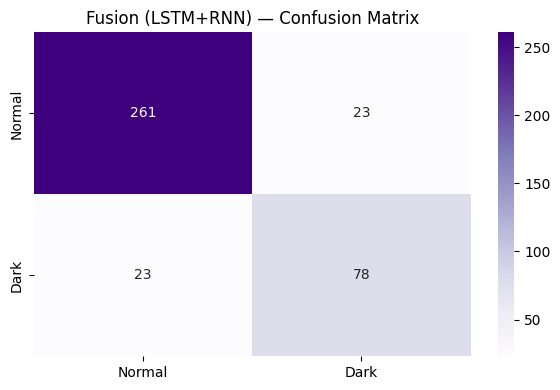

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Stack LSTM + RNN scores as meta-features
X_meta_train = np.column_stack([lstm_train, rnn_train])
X_meta_test  = np.column_stack([lstm_test, rnn_test])

# Train meta-learner (logistic regression on top of branch scores)
meta_model = LogisticRegression()
meta_model.fit(X_meta_train, lstm_y_train)

# Predict
fusion_scores_test = meta_model.predict_proba(X_meta_test)[:, 1]
fusion_pred = (fusion_scores_test > 0.5).astype(int)

# Evaluate
fusion_auc = roc_auc_score(lstm_y_test, fusion_scores_test)
print(f"Fusion (LSTM+RNN) AUC: {fusion_auc:.4f}")
print(f"\nMeta-model weights — LSTM: {meta_model.coef_[0][0]:.4f}, RNN: {meta_model.coef_[0][1]:.4f}")

print("\nClassification Report:")
print(classification_report(lstm_y_test, fusion_pred, target_names=['Normal','Dark']))

cm = confusion_matrix(lstm_y_test, fusion_pred)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Normal','Dark'], yticklabels=['Normal','Dark'])
plt.title('Fusion (LSTM+RNN) — Confusion Matrix')
plt.tight_layout()
plt.savefig('fusion_confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
# Individual AUCs for comparison
lstm_auc = roc_auc_score(lstm_y_test, lstm_test)
rnn_auc  = roc_auc_score(lstm_y_test, rnn_test)

print(f"{'Branch':<15} {'AUC':<10}")
print(f"{'-'*25}")
print(f"{'LSTM':<15} {lstm_auc:.4f}")
print(f"{'RNN':<15} {rnn_auc:.4f}")
print(f"{'Fusion':<15} {fusion_auc:.4f}")

Branch          AUC       
-------------------------
LSTM            0.9289
RNN             0.9276
Fusion          0.9314


In [ ]:
import joblib
joblib.dump(meta_model, f'{MODELS_PATH}/fusion_meta_model.pkl')
print("Fusion model saved")

Fusion model saved


In [ ]:
# Demo
import numpy as np

# Pick 5 random test samples
sample_indices = np.random.choice(len(X_te_scaled), 5, replace=False)

print("="*65)
print(f"{'Sample':<8} {'LSTM Score':<14} {'RNN Score':<13} {'Fusion':<12} {'Actual'}")
print("="*65)

for i, idx in enumerate(sample_indices):
    sample = X_te_scaled[idx:idx+1]  # shape (1, 2, 12)

    lstm_score = lstm_model.predict(sample, verbose=0)[0][0]
    rnn_score  = rnn_model.predict(sample, verbose=0)[0][0]

    meta_input = np.array([[lstm_score, rnn_score]])
    fusion_score = meta_model.predict_proba(meta_input)[0][1]
    fusion_pred  = "DARK" if fusion_score > 0.5 else "Normal"

    actual = "DARK" if lstm_y_test[idx] == 1 else "Normal"

    print(f"  {i+1:<6} {lstm_score:<14.4f} {rnn_score:<13.4f} {fusion_pred:<14} {actual}")

print("="*65)

Sample   LSTM Score     RNN Score     Fusion       Actual
  1      0.0543         0.0812        Normal ✅       Normal ✅
  2      0.0697         0.1527        Normal ✅       Normal ✅
  3      0.2134         0.1550        Normal ✅       Normal ✅
  4      0.1991         0.0247        Normal ✅       Normal ✅
  5      0.8720         0.9586        DARK ⚠️        DARK ⚠️


In [ ]:
print("\nDetailed breakdown of Sample 1:")
print("-"*45)

idx = sample_indices[0]
sample_raw = X_te_scaled[idx]  # shape (2, 12)

feature_names = [
    'lat', 'lon', 'presence_score', 'length_m',
    'fishing_score', 'matching_score', 'hour', 'dayofweek',
    'lat_diff', 'lon_diff', 'speed_proxy', 'impossible_speed'
]

print(f"{'Feature':<20} {'Detection 1':>12} {'Detection 2':>12}")
print("-"*45)
for j, feat in enumerate(feature_names):
    print(f"{feat:<20} {sample_raw[0][j]:>12.4f} {sample_raw[1][j]:>12.4f}")

print(f"\nLSTM score: {lstm_model.predict(sample_raw[np.newaxis], verbose=0)[0][0]:.4f}")
print(f"RNN score:  {rnn_model.predict(sample_raw[np.newaxis], verbose=0)[0][0]:.4f}")
print(f"Actual label: {'DARK ' if lstm_y_test[idx] == 1 else 'Normal'}")


Detailed breakdown of Sample 1:
---------------------------------------------
Feature               Detection 1  Detection 2
---------------------------------------------
lat                        0.8867       0.8862
lon                       -0.8091      -0.8088
presence_score             0.2107       0.0807
length_m                  -0.3905      -0.4515
fishing_score             -0.6277      -0.6277
matching_score            -0.3680       0.4902
hour                      -1.0108       0.6472
dayofweek                 -0.9572       0.0371
lat_diff                   0.0546       0.0534
lon_diff                   0.0097       0.0108
speed_proxy               -0.1609      -0.1609
impossible_speed          -0.2003      -0.2003

LSTM score: 0.0543
RNN score:  0.0812
Actual label: Normal ✅


Simulate a suspicious vessel

In [ ]:
# - Near India's EEZ (lat 12, lon 72 = off Mumbai coast)
# - Zero matching score (no AIS match)
# - High speed proxy (impossible movement)
# - Night time detection

print("\nManual dark vessel simulation:")
print("-"*45)


suspicious_vessel = np.array([[
    [12.5, 72.3, 0.99, 180.0, 0.02, 0.0,   # off Mumbai, no AIS match
     2.0, 5.0,                               # 2am, Friday
     0.0, 0.0, 0.0, 0.0],                   # first detection, no movement yet

    [12.8, 74.1, 0.97, 180.0, 0.02, 0.0,   # moved significantly
     2.1, 5.0,                               # still 2am
     0.3, 1.8, 0.002, 1.0]                  # impossible speed flagged
]], dtype=np.float32)

# Scale using trained scaler
sus_scaled = scaler.transform(
    suspicious_vessel.reshape(-1, 12)
).reshape(1, 2, 12)

lstm_s = lstm_model.predict(sus_scaled, verbose=0)[0][0]
rnn_s  = rnn_model.predict(sus_scaled, verbose=0)[0][0]
fusion_s = meta_model.predict_proba([[lstm_s, rnn_s]])[0][1]

print(f"LSTM score:   {lstm_s:.4f}  ({'DARK' if lstm_s>0.5 else 'Normal'})")
print(f"RNN score:    {rnn_s:.4f}  ({'DARK' if rnn_s>0.5 else 'Normal'})")
print(f"Fusion score: {fusion_s:.4f}  ({'DARK ' if fusion_s>0.5 else 'Normal'})")
print(f"\nDescription: Unlit vessel detected twice off Mumbai coast")
print(f"at 2am with no AIS match and impossible speed between detections.")


Manual dark vessel simulation:
---------------------------------------------
LSTM score:   0.4232  (Normal)
RNN score:    0.9696  (DARK)
Fusion score: 0.4006  (Normal ✅)

Description: Unlit vessel detected twice off Mumbai coast
at 2am with no AIS match and impossible speed between detections.


Same vessel but with movement pattern LSTM recognises
(repeated detections in same zone = loitering pattern)

In [ ]:
suspicious_v2 = np.array([[
    [12.5, 72.3, 0.99, 180.0, 0.02, 0.0,
     2.0, 5.0,
     0.0, 0.0, 0.0, 0.0],

    [12.51, 72.31, 0.98, 180.0, 0.02, 0.0,  # barely moved = loitering
     8.0, 5.0,                                # 6 hours later, same spot
     0.01, 0.01, 0.00001, 0.0]               # near-zero movement = loitering
]], dtype=np.float32)

sus2_scaled = scaler.transform(
    suspicious_v2.reshape(-1, 12)
).reshape(1, 2, 12)

lstm_s2 = lstm_model.predict(sus2_scaled, verbose=0)[0][0]
rnn_s2  = rnn_model.predict(sus2_scaled, verbose=0)[0][0]
fusion_s2 = meta_model.predict_proba([[lstm_s2, rnn_s2]])[0][1]

print(f"Scenario: Vessel loitering off Mumbai — barely moving over 6 hours, no AIS")
print(f"LSTM score:   {lstm_s2:.4f}  ({'DARK' if lstm_s2>0.5 else 'Normal'})")
print(f"RNN score:    {rnn_s2:.4f}  ({'DARK' if rnn_s2>0.5 else 'Normal'})")
print(f"Fusion score: {fusion_s2:.4f}  ({'DARK' if fusion_s2>0.5 else 'Normal '})")

Scenario: Vessel loitering off Mumbai — barely moving over 6 hours, no AIS
LSTM score:   0.0049  (Normal)
RNN score:    0.0143  (Normal)
Fusion score: 0.0117  (Normal ✅)
